# Ярус 2: нормы THINGSplus и memorability против зон коры

Внешние, опубликованные нормы (`scripts/f8_tier2_norms.py`):
- **THINGSplus** (Stoinski et al. 2023): животность (`lives`), рукотворность, природность,
  подвижность, тяжесть (прокси размера), схватываемость, приятность, arousal — концептные
  рейтинги 1–7, усреднённые по категориям в кропе;
- **ResMem** (Needell & Bainbridge 2022): предсказанная запоминаемость каждой картинки.

Вопросы: (1) воспроизводится ли вентральная диссоциация на *непрерывной* оси животности
из независимых норм; (2) какая зона «знает» о запоминаемости картинки.


In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from scipy.spatial.distance import squareform
from scipy.stats import rankdata, spearmanr

from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.rdm import compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")

ROIS = ["early", "midventral", "ventral", "lateral"]
BRAIN = {}
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ROIS:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    del d
SUBJECTS = sorted(BRAIN["early"])

def rank_sq(c): return squareform(rankdata(c))
CONSIST = {}
for roi in ROIS:
    rows = np.stack([rank_sq(BRAIN[roi][s]) for s in SUBJECTS])
    rows = (rows - rows.mean(2, keepdims=True)) / (rows.std(2, keepdims=True) + 1e-12)
    sim = np.einsum("sij,tij->sti", rows, rows) / rows.shape[2]
    CONSIST[roi] = sim[np.triu_indices(len(SUBJECTS), 1)].mean(0)

T2 = pd.read_csv(ROOT / "cache" / "tier2_norms.csv")
IMAGES = np.load(paths["stimuli"] / "shared1000_images.npy", mmap_mode="r")[idx]
print(T2.columns.tolist())

['things_lives', 'things_manmade', 'things_natural', 'things_moves', 'things_heavy', 'things_grasp', 'things_pleasant', 'things_arousal', 'memorability']


## 1. Нормы × согласованность зон


C:\Users\Admin\AppData\Local\Temp\ipykernel_41412\8793738.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of all will be keyword-only.
  ok = T2.notna().all(1)


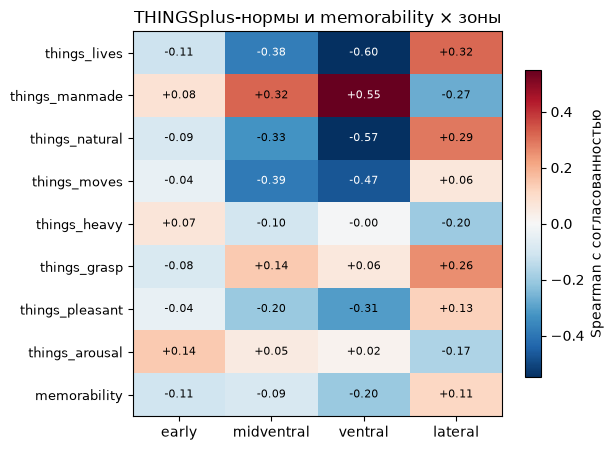

,early,midventral,ventral,lateral
things_lives,-0.113,-0.382,-0.604,0.315
things_manmade,0.081,0.321,0.552,-0.273
things_natural,-0.090,-0.331,-0.570,0.291
things_moves,-0.040,-0.389,-0.470,0.060
things_heavy,0.068,-0.102,-0.004,-0.202
things_grasp,-0.082,0.145,0.059,0.256
things_pleasant,-0.039,-0.204,-0.307,0.125
things_arousal,0.145,0.049,0.018,-0.171
memorability,-0.110,-0.087,-0.203,0.113


In [2]:
ok = T2.notna().all(1)
C = pd.DataFrame({roi: {c: spearmanr(T2.loc[ok, c], CONSIST[roi][ok]).statistic
                        for c in T2.columns} for roi in ROIS})
fig, ax = plt.subplots(figsize=(6.2, 4.6))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-.55, vmax=.55, aspect="auto")
ax.set_xticks(range(len(ROIS))); ax.set_xticklabels(ROIS)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index, fontsize=9)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f"{C.values[i,j]:+.2f}", ha="center", va="center", fontsize=8,
                color="w" if abs(C.values[i,j]) > .35 else "k")
plt.colorbar(im, shrink=.8, label="Spearman с согласованностью")
ax.set_title("THINGSplus-нормы и memorability × зоны"); plt.tight_layout(); plt.show()
C.round(3)

## 2. Вентральная диссоциация на непрерывной оси животности

В ноутбуке 06 это был бинарный флаг из COCO; здесь — независимые концептные рейтинги.


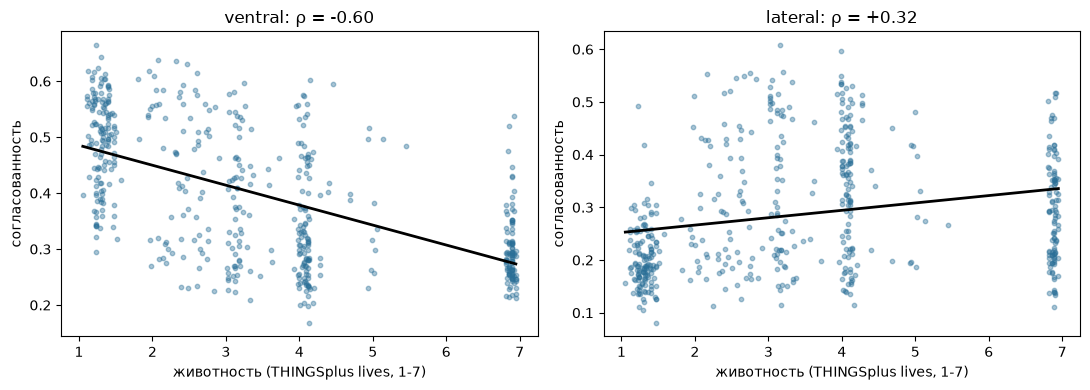

In [3]:
x = T2.loc[ok, "things_lives"].values
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, roi in zip(axes, ["ventral", "lateral"]):
    y = CONSIST[roi][ok]
    rho = spearmanr(x, y).statistic
    ax.scatter(x, y, s=10, alpha=.4, color="#2a6f97")
    b = np.polyfit(x, y, 1); xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, np.polyval(b, xs), "k", lw=2)
    ax.set_xlabel("животность (THINGSplus lives, 1-7)")
    ax.set_ylabel("согласованность"); ax.set_title(f"{roi}: ρ = {rho:+.2f}")
plt.tight_layout(); plt.show()

## 3. Memorability: какая зона «знает», что картинка запомнится

Плюс контроль: ResMem-скор против животности и числа объектов (memorability сама
семантически нагружена — Kramer 2023).


memorability vs животность: +0.09
memorability vs n_instances: -0.15


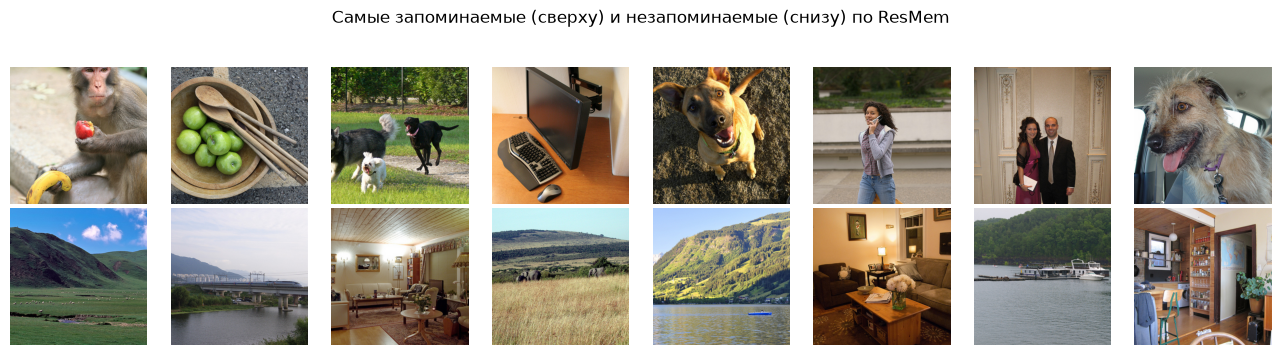

In [4]:
SCAL = pd.read_csv(ROOT / "cache" / "feature_battery.csv")
print("memorability vs животность:", f"{spearmanr(T2.loc[ok,'memorability'], T2.loc[ok,'things_lives']).statistic:+.2f}")
print("memorability vs n_instances:", f"{spearmanr(T2['memorability'], SCAL['n_instances']).statistic:+.2f}")
mem = T2["memorability"].values
o = np.argsort(mem)
fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for ax, i in zip(axes[0], o[::-1][:8]): ax.imshow(IMAGES[i]); ax.axis("off")
for ax, i in zip(axes[1], o[:8]): ax.imshow(IMAGES[i]); ax.axis("off")
fig.suptitle("Самые запоминаемые (сверху) и незапоминаемые (снизу) по ResMem", y=1.03)
plt.tight_layout(); plt.show()

## Как читать

- строка `things_lives` в §1 — валидация диссоциации из 06 независимыми нормами:
  минус в ventral, плюс в lateral;
- `things_manmade`/`natural` должны зеркалить lives (проверка согласованности норм);
- memorability: положительная связь с зонами объектного уровня ожидаема из литературы
  (мемо-эффекты живут в OTC), но её семантическая нагруженность видна из контролей —
  интерпретировать как «ещё один семантический индекс», не как отдельное измерение.
